# 2 - Geração e Extração de Tabelas de Busca (LUTs) Unidimensionais

Substituir a avaliação direta de polinômios de alta ordem por tabelas de busca (Lookup Tables - LUTs), conforme a técnica descrita na Figura 14 e na Tabela 2 das fontes. A atividade consiste em extrair um conjunto de Q valores complexos pré-calculados das funções geradas na etapa anterior, mapeando amplitudes de entrada para saídas complexas correspondentes, visando reduzir a complexidade de processamento.

In [3]:
from scipy.io import loadmat
import numpy as np


mat = loadmat('in_out_SBRT2_direto.mat')

in_data_ext = mat['in_extraction'].flatten()
out_data_ext = mat['out_extraction'].flatten()
in_data_val = mat['in_validation'].flatten()
out_data_val = mat['out_validation'].flatten()


In [4]:
def bloco_memoria_mp(x_delay, coef_m, ordem):
    """
    Implementa o bloco:
        sum_{p=1}^P b_{p,m} * x(n-m) * |x(n-m)|^(2*(p-1))

    x_delay : x(n-m) (vetor complexo)
    coef_m  : coeficientes complexos desse atraso (tamanho = ordem)
    ordem   : ordem do polinômio
    """
    y_m = np.zeros_like(x_delay, dtype=complex)

    for p in range(1, ordem + 1):
        y_m += coef_m[p-1] * x_delay * np.abs(x_delay)**(2*(p-1))

    return y_m


def mp_model(x_in, coef, ordem, memoria):
    """
    Modelo Memory Polynomial estruturado por blocos

    coef : vetor complexo organizado como:
           [b_{1,0}, ..., b_{P,0},
            b_{1,1}, ..., b_{P,1},
            ...
            b_{1,M}, ..., b_{P,M}]
    """
    N = len(x_in)
    y_est = np.zeros(N, dtype=complex)

    idx = 0
    for m in range(memoria + 1):
        # Atraso
        x_delay = np.roll(x_in, m)

        # Coeficientes desse bloco de memória
        coef_m = coef[idx:idx + ordem]
        idx += ordem

        # Bloco do somatório (figura que você mostrou)
        y_est += bloco_memoria_mp(x_delay, coef_m, ordem)

    return y_est

def erro_mp_complex_blocos(params, x_in, y_out, ordem, memoria):
    """
    Erro do modelo MP estruturado por blocos
    """
    C = len(params) // 2
    coef = params[:C] + 1j * params[C:]

    y_est = mp_model(x_in, coef, ordem, memoria)
    erro = y_out - y_est

    return np.abs(erro) 


In [5]:
from scipy.optimize import least_squares

ordem = 3
memoria = 2
num_coef = ordem * (memoria+1)

# Vetor inicial: separar parte real e imaginária
x0 = np.zeros(2*num_coef)

res = least_squares(
    erro_mp_complex_blocos,
    x0,
    args=(in_data_ext, out_data_ext, ordem, memoria),
    verbose=2
)

coef_otimo = res.x[:num_coef] + 1j*res.x[num_coef:]
print("Coeficientes complexos otimizados:", coef_otimo)

# Calcular MSE na validação
erro_val = erro_mp_complex_blocos(res.x, in_data_val, out_data_val, ordem, memoria)
mse_val = np.mean(erro_val**2)
print("MSE validação:", mse_val)


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.8318e+02                                    2.03e+03    
       1              2         6.2765e+02      2.56e+02       1.00e+00       1.93e+03    
       2              3         2.3404e+01      6.04e+02       8.97e-01       2.99e+02    
       3              4         3.0717e+00      2.03e+01       1.00e+00       2.55e+01    
       4              5         2.9170e+00      1.55e-01       5.01e-01       4.04e+01    
       5              6         2.6840e+00      2.33e-01       1.25e-01       3.07e+01    
       6              7         2.5120e+00      1.72e-01       3.13e-02       3.33e+01    
       7              9         2.3310e+00      1.81e-01       7.82e-03       1.46e+01    
       8             10         2.3155e+00      1.55e-02       7.82e-03       1.37e+01    
       9             11         2.2874e+00      2.81e-02       1.96e-03       2.98e+00    

valor de NMSE: -26.583997587165697


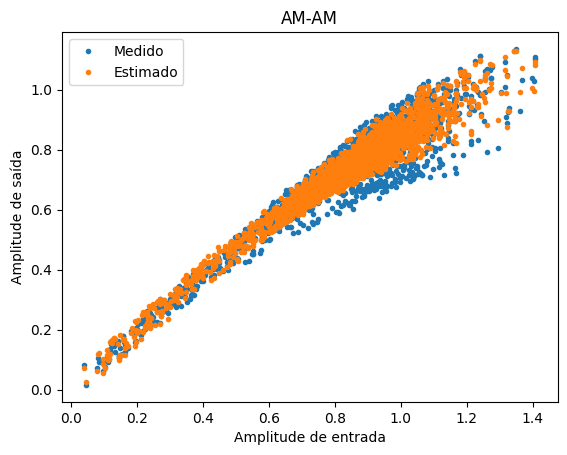

In [6]:
import matplotlib.pyplot as plt
nmse_calculo = lambda predicted_val, data_out:10 * np.log10(np.mean(np.abs(data_out - predicted_val) ** 2) / np.mean(np.abs(data_out) ** 2))

def mp(P, M, xn, coef):
    L = xn.shape[0]
    y_est = np.zeros(L, dtype=complex)

    idx = 0
    for k in range(M+1):
        xk = np.roll(xn, k)
        for p in range(1, P+1):
            y_est += coef[idx] * (xk * np.abs(xk)**((p-1)*2))
            idx += 1
    return y_est


predicted_val = mp(ordem, memoria, in_data_val, coef_otimo)

nmse_calculado = nmse_calculo(predicted_val[memoria:], out_data_val[memoria:])
print(f"valor de NMSE: {nmse_calculado}")
plt.figure()
plt.plot(np.abs(in_data_val[memoria:]), np.abs(out_data_val[memoria:]), '.', label='Medido')
plt.plot(np.abs(in_data_val[memoria:]), np.abs(predicted_val[memoria:]), '.', label='Estimado')
plt.xlabel('Amplitude de entrada')
plt.ylabel('Amplitude de saída')
plt.title('AM-AM')
plt.legend()

plt.show()

In [7]:
def bloco_memoria_lut(x_delay, r_grid, lut):
    """
    Implementa um ramo de memória usando LUT
    """
    r = np.abs(x_delay)

    # Interpolação linear
    f_interp = np.interp(
        r,
        r_grid,
        lut.real
    ) + 1j * np.interp(
        r,
        r_grid,
        lut.imag
    )

    return x_delay * f_interp

def mp_model_lut(x_in, luts, r_grids, memoria):
    """
    Modelo MP usando LUTs unidimensionais
    """
    y_est = np.zeros(len(x_in), dtype=complex)

    for m in range(memoria + 1):
        x_delay = np.roll(x_in, m)
        y_est += bloco_memoria_lut(
            x_delay,
            r_grids[m],
            luts[m]
        )

    return y_est


In [10]:
def funcao_radial_mp(r, coef_m, ordem):
    """
    Calcula:
    f_m(r) = sum_{p=1}^P b_{p,m} * r^(2*(p-1))
    """
    f = np.zeros_like(r, dtype=complex)

    for p in range(1, ordem + 1):
        f += coef_m[p-1] * r**(2*(p-1))

    return f

def gerar_lut_mp(coef_m, ordem, r_max, Q):
    """
    Gera LUT unidimensional para um termo de memória m
    """
    r_grid = np.linspace(0, r_max, Q)
    lut = funcao_radial_mp(r_grid, coef_m, ordem)
    return r_grid, lut

Q = 256
r_max = np.max(np.abs(in_data_ext))

r_grids = []
luts = []

idx = 0
for m in range(memoria + 1):
    coef_m = coef_otimo[idx:idx + ordem]
    idx += ordem

    r_grid, lut = gerar_lut_mp(coef_m, ordem, r_max, Q)
    r_grids.append(r_grid)
    luts.append(lut)


valor de NMSE: -26.583989947843026


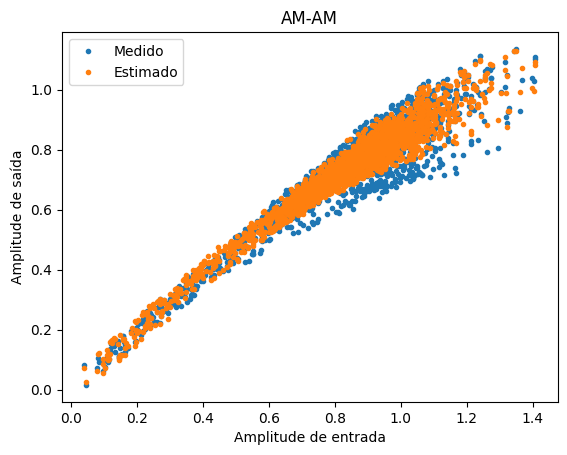

In [11]:



import matplotlib.pyplot as plt
nmse_calculo = lambda predicted_val, data_out:10 * np.log10(np.mean(np.abs(data_out - predicted_val) ** 2) / np.mean(np.abs(data_out) ** 2))

def mp_model_lut(x_in, luts, r_grids, memoria):
    """
    Modelo MP usando LUTs unidimensionais
    """
    y_est = np.zeros(len(x_in), dtype=complex)

    for m in range(memoria + 1):
        x_delay = np.roll(x_in, m)
        y_est += bloco_memoria_lut(
            x_delay,
            r_grids[m],
            luts[m]
        )

    return y_est

predicted_val_lut = mp_model_lut(
    in_data_val,
    luts,
    r_grids,
    memoria
)

nmse_calculado = nmse_calculo(predicted_val_lut[memoria:], out_data_val[memoria:])
print(f"valor de NMSE: {nmse_calculado}")
plt.figure()
plt.plot(np.abs(in_data_val[memoria:]), np.abs(out_data_val[memoria:]), '.', label='Medido')
plt.plot(np.abs(in_data_val[memoria:]), np.abs(predicted_val_lut[memoria:]), '.', label='Estimado')
plt.xlabel('Amplitude de entrada')
plt.ylabel('Amplitude de saída')
plt.title('AM-AM')
plt.legend()

plt.show()
